In [ ]:
# importing the dependecies
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader

In [ ]:
# Set random seed for reproducibility
# This ensures:
# Same initial weights
# Same random choices
# Same training behavior (as much as possible)

torch.manual_seed(42)

In [ ]:
# checking the availability of gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:{device}")

Using device:cuda


In [ ]:
# Install the Kaggle API
!pip install kaggle

In [ ]:
# loading the dataset from kaggle server to google colab
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
fashionmnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/fashionmnist.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/fashion-mnist_train.csv')

In [ ]:
df.shape

(60000, 785)

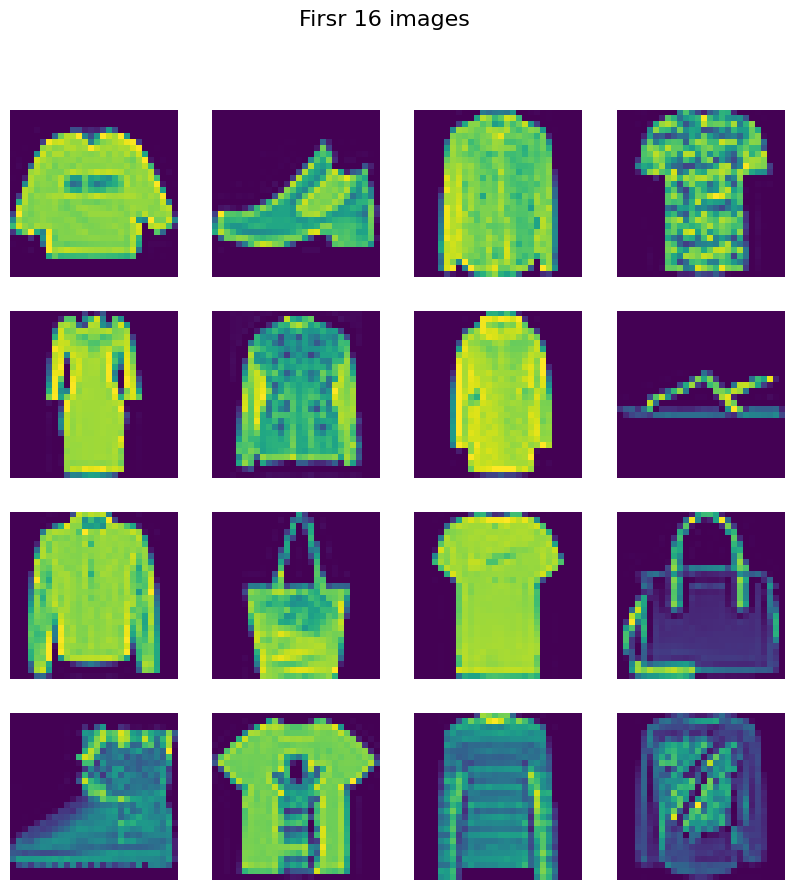

In [ ]:
# visualizing on 4x4 grid
fig,axes = plt.subplots(4,4,figsize=(10,10))
plt.suptitle("Firsr 16 images",fontsize=16)

# plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# separating the features and target
x = df.drop(columns=['label'],axis=1)
y = df['label']

In [ ]:
x

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y

,label
0,2
1,9
2,6
3,0
4,3
...,...
59995,9
59996,1
59997,8
59998,8


In [ ]:
# train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(60000, 784) (48000, 784) (12000, 784)


In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):

    # convert to Pytorch tensors
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]

In [ ]:
train_dataset = CustomDataset(x_train.values,y_train.values)

In [ ]:
test_dataset = CustomDataset(x_test.values,y_test.values)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [ ]:
len(train_loader)

1500

In [ ]:
# creating our model
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
learning_rate = 0.1
epochs = 100

In [ ]:
# instantiate the model
model = MyNN(x_train.shape[1])

# moving our model to gpu
model = model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(),lr = learning_rate,weight_decay=1e-4)

In [ ]:
# training loop

for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:

    # move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    # forward pass
    output =  model(batch_features)

    # calculate loss
    loss = criterion(output,batch_labels)

    # back pss
    optimizer.zero_grad() #clears old gradients
    loss.backward()

    # update grad
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f"Epoch:{epoch + 1},Loss : {avg_loss}")

Epoch:1,Loss : 0.5790093433956305
Epoch:2,Loss : 0.45404486179351805
Epoch:3,Loss : 0.4146016920357943
Epoch:4,Loss : 0.3908622784713904
Epoch:5,Loss : 0.3763451832930247
Epoch:6,Loss : 0.3665035707106193
Epoch:7,Loss : 0.3530690363695224
Epoch:8,Loss : 0.3467472512672345
Epoch:9,Loss : 0.33324655205011366
Epoch:10,Loss : 0.3265992530733347
Epoch:11,Loss : 0.3220274396215876
Epoch:12,Loss : 0.3157223462065061
Epoch:13,Loss : 0.31108853182196616
Epoch:14,Loss : 0.3055510268881917
Epoch:15,Loss : 0.3002403910557429
Epoch:16,Loss : 0.29460327412188053
Epoch:17,Loss : 0.2933059433052937
Epoch:18,Loss : 0.2889194576938947
Epoch:19,Loss : 0.28526972416291635
Epoch:20,Loss : 0.28525599487622577
Epoch:21,Loss : 0.2818351363092661
Epoch:22,Loss : 0.2768779086222251
Epoch:23,Loss : 0.27704834286371866
Epoch:24,Loss : 0.27222149123748146
Epoch:25,Loss : 0.2710339842066169
Epoch:26,Loss : 0.27141732825587195
Epoch:27,Loss : 0.2647932243471344
Epoch:28,Loss : 0.26723931956042846
Epoch:29,Loss : 0.2

In [ ]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation code
total = 0
correct = 0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:

    # move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    output = model(batch_features)

    _,predicted = torch.max(output,1)

    total = total + batch_labels.size(0)

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8905


In [ ]:
# evaluation code
total = 0
correct = 0
with torch.no_grad():
  for batch_features,batch_labels in train_loader:

    # move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    output = model(batch_features)

    _,predicted = torch.max(output,1)

    total = total + batch_labels.size(0)

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.957875


In [ ]:
# The model that we used elarlier has 88% accuracy on testing and 98% accuracy on training , means overfitting
# here we use L2 regularization,Batchnormalization,and dropout and get 89% accuracy on testing and 95% accuracy on traing.

# That means we reduce the gap of 10 %  to 5% that we have earlier.